<a href="https://colab.research.google.com/github/Inesvvv/ML_Project/blob/main/knn_Model_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Features remaining after correlation filter: 539

Dummy baseline accuracy: 0.725
k=1   weights=uniform  metric=manhattan  -> CV ROC-AUC: 0.707
k=1   weights=uniform  metric=euclidean  -> CV ROC-AUC: 0.685
k=1   weights=distance metric=manhattan  -> CV ROC-AUC: 0.707
k=1   weights=distance metric=euclidean  -> CV ROC-AUC: 0.685
k=3   weights=uniform  metric=manhattan  -> CV ROC-AUC: 0.748
k=3   weights=uniform  metric=euclidean  -> CV ROC-AUC: 0.783
k=3   weights=distance metric=manhattan  -> CV ROC-AUC: 0.753
k=3   weights=distance metric=euclidean  -> CV ROC-AUC: 0.782
k=5   weights=uniform  metric=manhattan  -> CV ROC-AUC: 0.766
k=5   weights=uniform  metric=euclidean  -> CV ROC-AUC: 0.811
k=5   weights=distance metric=manhattan  -> CV ROC-AUC: 0.768
k=5   weights=distance metric=euclidean  -> CV ROC-AUC: 0.812
k=7   weights=uniform  metric=manhattan  -> CV

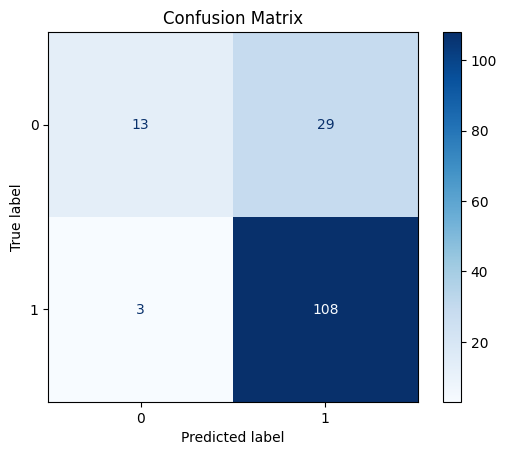

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')


# load
df = pd.read_csv("/content/drive/MyDrive/Machine_Learning_Project/ML_notebooks/pd_speech_features.csv", skiprows=1)


# split variables
X = df.drop(columns=["class", "id"])
y = df["class"]
groups = df["id"]


# grouped train/test split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


# remove highly correlated features using train set only
corr = X_train.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.96)]
X_train = X_train.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)

print(f"Features remaining after correlation filter: {X_train.shape[1]}")


# --- dummy baseline ---
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
print(f"\nDummy baseline accuracy: {dummy.score(X_test, y_test):.3f}")


# --- hyperparameter tuning ---
k_range = [1, 3, 5, 7, 9, 11, 15, 21, 31]
cv = GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=42)  # changed
train_groups = groups.iloc[train_idx]

scores_mean = []
configs = []

for k in k_range:
    for weights in ["uniform", "distance"]:
        for p in [1, 2]:   # 1 = Manhattan, 2 = Euclidean
            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("model", KNeighborsClassifier(
                    n_neighbors=k,
                    weights=weights,
                    p=p
                ))
            ])

            scores = cross_val_score(
    pipe,
    X_train,
    y_train,
    cv=cv,            # changed
    groups=train_groups,
    scoring="roc_auc"
)

            scores_mean.append(scores.mean())
            configs.append({
                "n_neighbors": k,
                "weights": weights,
                "p": p
            })

            metric_name = "manhattan" if p == 1 else "euclidean"
            print(f"k={k:<3} weights={weights:<8} metric={metric_name:<10} -> CV ROC-AUC: {scores.mean():.3f}")


best_config = configs[np.argmax(scores_mean)]
print(f"\nBest config: {best_config}")
print(f"Best CV ROC-AUC: {max(scores_mean):.3f}")


# --- retrain with best config and evaluate on test set ---
best_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(
        n_neighbors=best_config["n_neighbors"],
        weights=best_config["weights"],
        p=best_config["p"]
    ))
])

best_pipe.fit(X_train, y_train)

pred = best_pipe.predict(X_test)
proba = best_pipe.predict_proba(X_test)[:, 1]


# --- threshold analysis ---
for t in [0.3, 0.35, 0.4, 0.45, 0.5]:
    pred_t = (proba >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, pred_t))


print("\nDefault threshold = 0.5")
print(classification_report(y_test, pred))
print(f"Test ROC-AUC: {roc_auc_score(y_test, proba):.3f}")


# --- confusion matrix ---
ConfusionMatrixDisplay.from_estimator(best_pipe, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()